In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)

df['Target_Price'] = california.target

print(df.info())

print("--- PRIME 5 RIGHE ---")
print(df.head())

print("\n--- CORRELAZIONE CON IL PREZZO ---")
print(df.corr()['Target_Price'].sort_values(ascending=False))


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MedInc        20640 non-null  float64
 1   HouseAge      20640 non-null  float64
 2   AveRooms      20640 non-null  float64
 3   AveBedrms     20640 non-null  float64
 4   Population    20640 non-null  float64
 5   AveOccup      20640 non-null  float64
 6   Latitude      20640 non-null  float64
 7   Longitude     20640 non-null  float64
 8   Target_Price  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
--- PRIME 5 RIGHE ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
model = DecisionTreeRegressor()

features = df[['MedInc', 'AveRooms', 'HouseAge', 'Longitude', 'Latitude']]

X_train, X_test, y_train, y_test = train_test_split(features, df['Target_Price'], test_size=0.3, random_state=42)

model.fit(X_train, y_train)

print('Score:', model.score(X_test, y_test))

Score: 0.6062105106412535


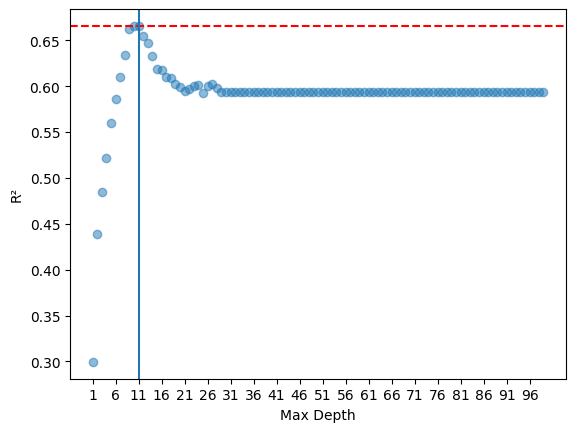

Best num of depth: 11


In [3]:
test_score = []

for i in range(1, 100):
    test_tree = DecisionTreeRegressor(max_depth=i, random_state=42) 
    test_tree.fit(X_train, y_train)
    test_score.append([test_tree.score(X_test, y_test), i])

import matplotlib.pyplot as plt

depths = [s[1] for s in test_score]    
r2_scores = [s[0] for s in test_score]  
best_r2 = max(r2_scores)

plt.scatter(depths, r2_scores, alpha=0.5)
plt.axhline(y=best_r2, color='r', ls='--')
plt.axvline(x=depths[r2_scores.index(best_r2)])
plt.xlabel('Max Depth'); plt.ylabel('R²')
plt.xticks(range(1, 101, 5))
plt.show()
plt.close()

best_depth = depths[r2_scores.index(best_r2)]
print('Best num of depth:', best_depth)

In [4]:
best_depth_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_depth_tree.fit(X_train, y_train)
print('Score con best depth:', best_depth_tree.score(X_test, y_test))

Score con best depth: 0.6657617116110336


In [7]:
test_score = []  
path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
tot_ccp_alphas = len(ccp_alphas)

for i in range(tot_ccp_alphas):
    print(f"\rProgress: {i/tot_ccp_alphas:.1%}", end='')
    tree = DecisionTreeRegressor(ccp_alpha=ccp_alphas[i], random_state=42)
    tree.fit(X_train, y_train)
    r2 = tree.score(X_test, y_test)
    test_score.append([r2, i])  


r2_scores = [s[0] for s in test_score]
best_r2 = max(r2_scores)
best_idx = r2_scores.index(best_r2) 
best_ccp = ccp_alphas[best_idx]    

print(f"Best CCP alpha: {best_ccp:.2e}, R²: {best_r2:.4f}")


Progress: 76.0%

KeyboardInterrupt: 

In [ ]:
best_model = DecisionTreeRegressor(ccp_alpha=best_ccp, random_state=42)
best_model.fit(X_train, y_train)

print(best_model.score(X_test, y_test))

0.6808727713380676


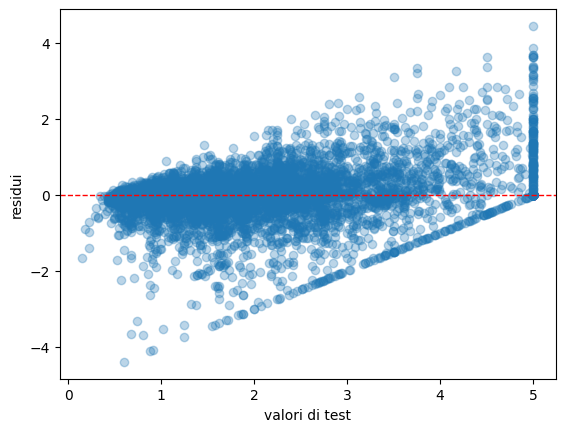

<Figure size 640x480 with 0 Axes>

In [ ]:
residuals = y_test - best_model.predict(X_test)

import matplotlib.pyplot as plt

plt.scatter(y_test, residuals, alpha=0.3)
plt.xlabel('valori di test')
plt.ylabel('residui')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()
plt.clf()

1. Il "Muro" a 5.0 nel Dataset

Nel dataset originale della California, per motivi di privacy o di standardizzazione statistica dell'epoca, tutti i valori delle case superiori a $500.000 sono stati forzatamente arrotondati a 5.0.

    In quel gruppo "5.0" non ci sono solo case da $500k, ma anche ville da $1.000.000 o $2.000.000.​

    Per il dataset, però, valgono tutte esattamente 5.0.​

2. Perché lo spread dei residui aumenta

Il tuo modello di regressione lineare cerca di essere onesto: vede una casa con 10 stanze, in un quartiere ricchissimo sulla costa, e calcola che dovrebbe valere 2.0 ($200k).​

    Calcolo del residuo: Residuo = Valore Reale - Valore Predetto.

    Se la casa è una di quelle "tagliate", il valore reale nel dataset è 5.0.

    Il tuo residuo sarà: 5.0 - 2.0 = \mathbf{+3.0}.​

Ecco perché vedi quei punti schizzare in alto verticalmente proprio quando il valore di test (y_test) è 5.0: sono tutte le case che il modello ha "sottostimato" perché non poteva sapere che erano ville di lusso mascherate da case normali.